In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("../data/cleaned_churn.csv")

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29,29,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56,1889,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,53,108,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,42,1840,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70,151,1,0,0,0,1,0,1,0


In [4]:
df['AvgSpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [5]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend
0,0,0,1,0,1,0,0,0,1,0,...,29,0,0,0,0,1,0,0,0,14.500000
1,1,0,0,0,34,1,0,1,0,1,...,1889,0,1,0,0,0,1,0,0,53.971429
2,1,0,0,0,2,1,0,1,1,0,...,108,1,0,0,0,0,1,0,0,36.000000
3,1,0,0,0,45,0,0,1,0,1,...,1840,0,1,0,0,0,0,0,0,40.000000
4,0,0,0,0,2,1,0,0,0,0,...,151,1,0,0,0,1,0,1,0,50.333333


In [6]:
df['TenureGroup'] = pd.cut(df['tenure'],
                          bins=[0,12,24,48,72],
                          labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [7]:
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4-6yr
0,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,14.500000,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,53.971429,False,True,False
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,1,0,0,36.000000,False,False,False
3,1,0,0,0,45,0,0,1,0,1,...,0,0,0,0,0,0,40.000000,False,True,False
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,0,1,0,50.333333,False,False,False


In [20]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4-6yr
0,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,14,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,53,0,1,0
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,1,0,0,36,0,0,0
3,1,0,0,0,45,0,0,1,0,1,...,0,0,0,0,0,0,40,0,1,0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,0,1,0,50,0,0,0


<Axes: >

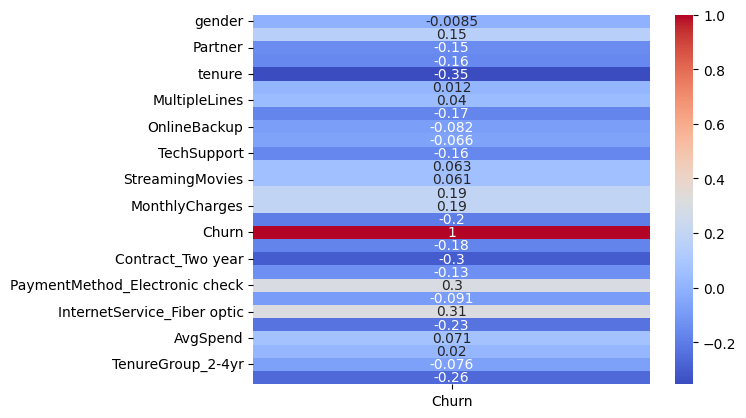

In [10]:
sns.heatmap(df.select_dtypes(include='number').corr()[['Churn']], annot=True, cmap='coolwarm')

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1033
           1       0.57      0.48      0.52       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.76      1407



In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [27]:
print(importance.head(50))

                                  Feature  Importance
21            InternetService_Fiber optic    0.472738
17                      Contract_Two year    0.156293
22                     InternetService_No    0.092806
16                      Contract_One year    0.065906
12                        StreamingMovies    0.019388
4                                  tenure    0.019156
7                          OnlineSecurity    0.012022
5                            PhoneService    0.011757
6                           MultipleLines    0.011077
19         PaymentMethod_Electronic check    0.010654
11                            StreamingTV    0.010455
10                            TechSupport    0.009611
1                           SeniorCitizen    0.009355
14                         MonthlyCharges    0.009198
13                       PaperlessBilling    0.008853
3                              Dependents    0.008118
15                           TotalCharges    0.007986
8                           

In [17]:
import shap

c:\Users\rohan\OneDrive\Desktop\Telco Customer Churn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


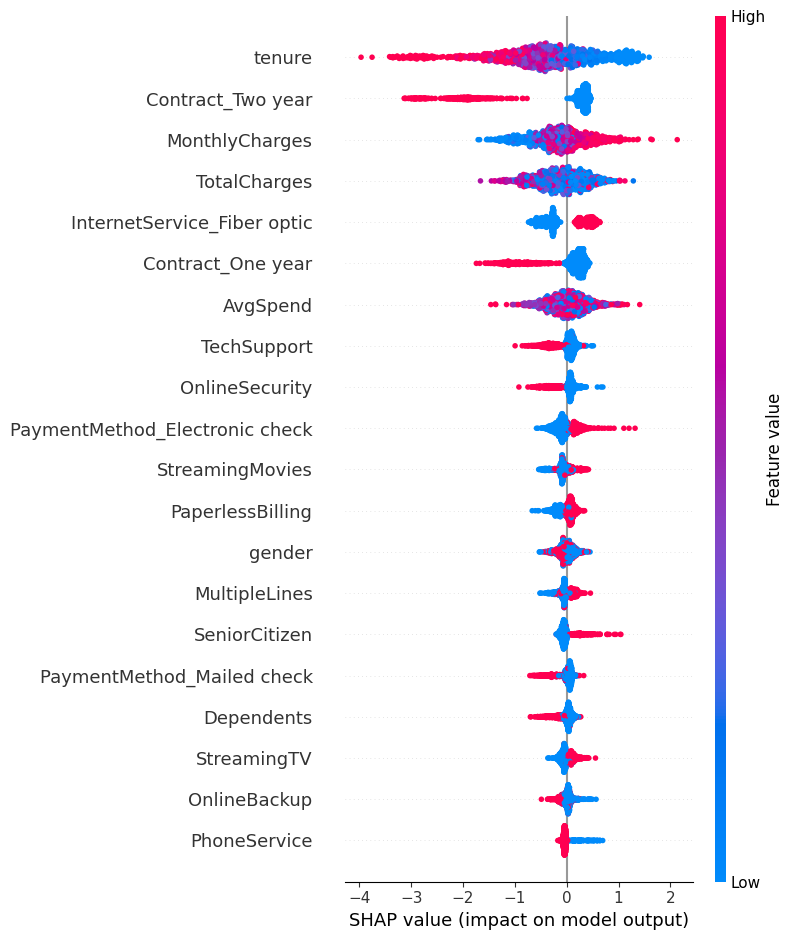

In [18]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [28]:

df['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [29]:
model = XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
)

###number of non-churn / number of churn
Example (your data)

Let’s say:

Non-churn = 5000
Churn = 1800

5000 / 1800 ≈ 2.7

scale_pos_weight = 2.7
1 churn mistake = 2.7 times more serious